In [42]:
from pathlib import Path
from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split

import math
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

from torchvision import transforms
from torchvision.datasets import ImageFolder

from scipy.fftpack import dct

from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor
from timm.models.vision_transformer import Block

import random
import json
import cv2

In [4]:
# CUDA 사용 가능 여부 확인
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

if torch.cuda.is_available():

    print("GPU name:", torch.cuda.get_device_name(0))

    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

else:
    print("CUDA is not available.")

Device: cuda
GPU name: NVIDIA GeForce RTX 5060 Laptop GPU
GPU memory: 7.96 GB


In [5]:
# 프로젝트 경로 설정
PROJECT_ROOT = Path.home() / "DCT_ViT"
DATA_ROOT = PROJECT_ROOT / "dataset"

# train 데이터는 4개 폴더로 나뉘어 있음
TRAIN_ROOTS = [
    DATA_ROOT / "train.X1",
    DATA_ROOT / "train.X2",
    DATA_ROOT / "train.X3",
    DATA_ROOT / "train.X4",
]

# validation 데이터
VAL_ROOT = DATA_ROOT / "val.X"

# 이후 전처리와 DCT에서 사용할 기본 설정
INPUT_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

assert INPUT_SIZE % 8 == 0, "INPUT_SIZE must be divisible by 8 for 8x8 DCT blocks."

# 경로 확인
assert PROJECT_ROOT.exists(), f"PROJECT_ROOT not found: {PROJECT_ROOT}"
assert DATA_ROOT.exists(), f"DATA_ROOT not found: {DATA_ROOT}"

for train_root in TRAIN_ROOTS:
    assert train_root.exists(), f"Train folder not found: {train_root}"

assert VAL_ROOT.exists(), f"Validation folder not found: {VAL_ROOT}"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("Train roots:")
for train_root in TRAIN_ROOTS:
    print(" ", train_root)

print("Validation root:", VAL_ROOT)

PROJECT_ROOT: /home/kyjoo/DCT_ViT
DATA_ROOT: /home/kyjoo/DCT_ViT/dataset
Train roots:
  /home/kyjoo/DCT_ViT/dataset/train.X1
  /home/kyjoo/DCT_ViT/dataset/train.X2
  /home/kyjoo/DCT_ViT/dataset/train.X3
  /home/kyjoo/DCT_ViT/dataset/train.X4
Validation root: /home/kyjoo/DCT_ViT/dataset/val.X


In [4]:
# train dataset 불러오기
train_datasets = []

for train_root in TRAIN_ROOTS:

    dataset = ImageFolder(
        root=train_root,
        transform=None
    )

    train_datasets.append(dataset)

    print(f"{train_root.name}: {len(dataset)} images")


# validation dataset 불러오기
val_dataset = ImageFolder(
    root=VAL_ROOT,
    transform=None
)

print(f"{VAL_ROOT.name}: {len(val_dataset)} images")


# train 클래스 정보 확인
print("\nNumber of classes:", len(train_datasets[0].classes))

print("\nFirst classes:")
print(train_datasets[0].classes[:10])


# train 데이터셋 총 크기 계산
total_train_samples = sum(len(dataset) for dataset in train_datasets)

print("\nTotal train samples:", total_train_samples)
print("Validation samples:", len(val_dataset))

train.X1: 32500 images
train.X2: 32500 images
train.X3: 32500 images
train.X4: 32500 images
val.X: 5000 images

Number of classes: 25

First classes:
['n01440764', 'n01484850', 'n01494475', 'n01531178', 'n01632777', 'n01665541', 'n01687978', 'n01695060', 'n01749939', 'n01775062']

Total train samples: 130000
Validation samples: 5000


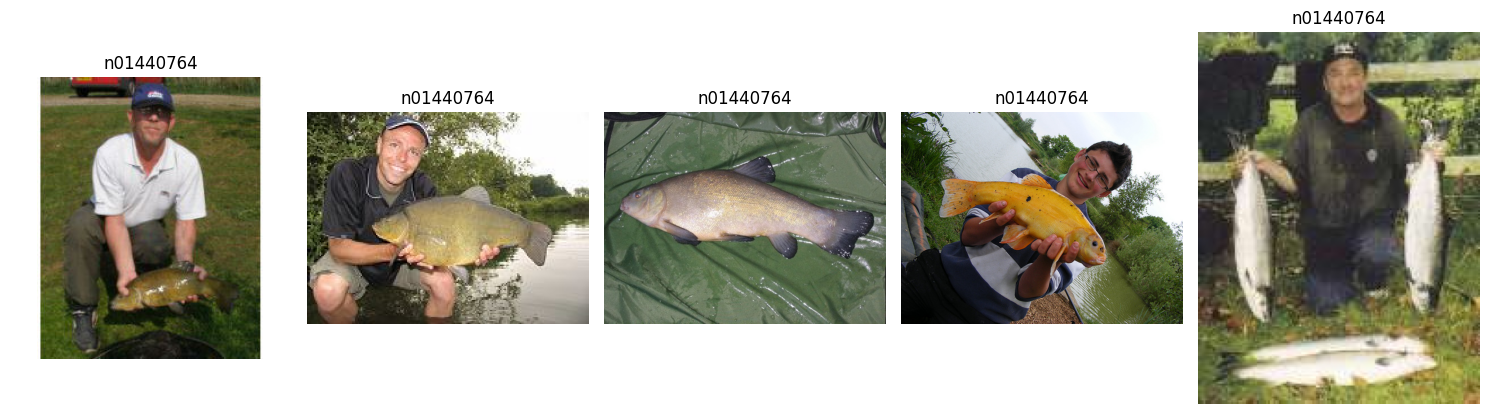

In [5]:
# 원본 이미지 확인
split_idx = 0  # 0: train.X1, 1: train.X2, 2: train.X3, 3: train.X4
NUM_IMAGES = 5

dataset = train_datasets[split_idx]

fig, axes = plt.subplots(1, NUM_IMAGES, figsize=(15, 5))

for i in range(NUM_IMAGES):
    image, label = dataset[i]

    class_name = dataset.classes[label]

    axes[i].imshow(image)
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [6]:
import json

# label json 불러오기
LABEL_PATH = DATA_ROOT / "Labels.json"

with open(LABEL_PATH, "r", encoding="utf-8") as f:
    LABELS = json.load(f)

print("Number of label names:", len(LABELS))
print("Example:", list(LABELS.items())[:5])

Number of label names: 100
Example: [('n01968897', 'chambered nautilus, pearly nautilus, nautilus'), ('n01770081', 'harvestman, daddy longlegs, Phalangium opilio'), ('n01818515', 'macaw'), ('n02011460', 'bittern'), ('n01496331', 'electric ray, crampfish, numbfish, torpedo')]


In [7]:
class ResizeWithPadding:
    """
    원본 이미지의 비율을 유지한 채 224x224 정사각형으로 변환한다.
    부족한 영역은 padding으로 채운다.
    """

    def __init__(self, size=224, fill=0):
        assert size % 8 == 0, "size must be divisible by 8 for 8x8 DCT blocks."

        self.size = size
        self.fill = fill

    def __call__(self, img):
        img = img.convert("RGB")

        img.thumbnail((self.size, self.size))

        w, h = img.size

        pad_w = self.size - w
        pad_h = self.size - h

        padding = (
            pad_w // 2,
            pad_h // 2,
            pad_w - pad_w // 2,
            pad_h - pad_h // 2,
        )

        img = ImageOps.expand(
            img,
            border=padding,
            fill=self.fill
        )

        return img

In [8]:
class RGBToYCrCb:
    """
    RGB Tensor를 OpenCV 기반 YCrCb Tensor로 변환한다.

    OpenCV 채널 순서:
        [Y, Cr, Cb]
    """

    def __call__(self, img):

        # [C, H, W] -> [H, W, C]
        img = img.permute(1, 2, 0).numpy()

        # float32 유지
        img = img.astype(np.float32)

        # RGB -> YCrCb
        img = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)

        # numpy -> torch tensor
        img = torch.from_numpy(img)

        # [H, W, C] -> [C, H, W]
        img = img.permute(2, 0, 1)

        return img

In [9]:
def make_radial_order(n=8):
    """
    실제 주파수 크기 r² = u² + v² 기준 정렬

    같은 r² 그룹 내부는
    (u, v) 사전식 순서로 고정한다.
    """

    groups = {}

    for u in range(n):
        for v in range(n):

            r2 = u * u + v * v

            groups.setdefault(r2, []).append((u, v))

    radial_groups = []

    for r2 in sorted(groups.keys()):

        group = sorted(groups[r2])

        radial_groups.append(group)

    return radial_groups


RADIAL_GROUPS = make_radial_order(8)

for i, group in enumerate(RADIAL_GROUPS):
    print(i, group)

0 [(0, 0)]
1 [(0, 1), (1, 0)]
2 [(1, 1)]
3 [(0, 2), (2, 0)]
4 [(1, 2), (2, 1)]
5 [(2, 2)]
6 [(0, 3), (3, 0)]
7 [(1, 3), (3, 1)]
8 [(2, 3), (3, 2)]
9 [(0, 4), (4, 0)]
10 [(1, 4), (4, 1)]
11 [(3, 3)]
12 [(2, 4), (4, 2)]
13 [(0, 5), (3, 4), (4, 3), (5, 0)]
14 [(1, 5), (5, 1)]
15 [(2, 5), (5, 2)]
16 [(4, 4)]
17 [(3, 5), (5, 3)]
18 [(0, 6), (6, 0)]
19 [(1, 6), (6, 1)]
20 [(2, 6), (6, 2)]
21 [(4, 5), (5, 4)]
22 [(3, 6), (6, 3)]
23 [(0, 7), (7, 0)]
24 [(1, 7), (5, 5), (7, 1)]
25 [(4, 6), (6, 4)]
26 [(2, 7), (7, 2)]
27 [(3, 7), (7, 3)]
28 [(5, 6), (6, 5)]
29 [(4, 7), (7, 4)]
30 [(6, 6)]
31 [(5, 7), (7, 5)]
32 [(6, 7), (7, 6)]
33 [(7, 7)]


In [10]:
# 추가
RADIAL_ORDER = [
    pos
    for group in RADIAL_GROUPS
    for pos in group
]

In [11]:
def blockwise_dct(channel_tensor):
    """
    입력:
        Tensor [224, 224]

    출력:
        Tensor [28, 28, 64]

    각 8x8 block의 DCT 계수를
r² = u² + v² 기준 radial order로 정렬한다.
같은 r² 그룹 내부 순서는
(u, v) 사전식 순서로 고정된다.
    """

    h, w = channel_tensor.shape

    assert h % 8 == 0
    assert w % 8 == 0

    blocks_h = h // 8
    blocks_w = w // 8

    channel = channel_tensor.detach().cpu().numpy()

    dct_blocks = []

    for by in range(blocks_h):
        row_blocks = []

        for bx in range(blocks_w):
            y0 = by * 8
            x0 = bx * 8

            block = channel[y0:y0 + 8, x0:x0 + 8]

            block_dct = dct(
                dct(block.T, norm="ortho").T,
                norm="ortho"
            )

            block_vec = [
                block_dct[i, j]
                for i, j in RADIAL_ORDER
            ]

            block_vec = torch.tensor(
                block_vec,
                dtype=torch.float32
            )

            row_blocks.append(block_vec)

        row_blocks = torch.stack(row_blocks)
        dct_blocks.append(row_blocks)

    dct_blocks = torch.stack(dct_blocks)

    return dct_blocks

In [12]:
all_samples = []
val_samples = []
class_names = set()

IMAGE_EXTENSIONS = {".jpeg", ".jpg", ".JPEG", ".JPG"}

for train_root in TRAIN_ROOTS:
    image_paths = [
        p for p in train_root.rglob("*")
        if p.is_file() and p.suffix in IMAGE_EXTENSIONS
    ]

    print(f"{train_root.name}: {len(image_paths)} images")

    for image_path in sorted(image_paths):
        class_name = image_path.parent.name

        class_names.add(class_name)
        all_samples.append((image_path, class_name))
val_image_paths = [
    p for p in VAL_ROOT.rglob("*")
    if p.is_file() and p.suffix in IMAGE_EXTENSIONS
]
print(f"{VAL_ROOT.name}: {len(val_image_paths)} images")
for image_path in sorted(val_image_paths):
    class_name = image_path.parent.name

    # train에 없던 class면 추가
    class_names.add(class_name)

    val_samples.append((image_path, class_name))


print("Total collected images:", len(all_samples))
print("Number of classes:", len(class_names))

train.X1: 32500 images
train.X2: 32500 images
train.X3: 32500 images
train.X4: 32500 images
val.X: 5000 images
Total collected images: 130000
Number of classes: 100


In [13]:
assert len(all_samples) > 0, "No image files were collected. Check folder structure or file extensions."

class_names = sorted(class_names)

CLASS_TO_IDX = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

IDX_TO_CLASS = {
    idx: class_name
    for class_name, idx in CLASS_TO_IDX.items()
}

all_image_paths = [sample[0] for sample in all_samples]
all_labels = [CLASS_TO_IDX[sample[1]] for sample in all_samples]
val_paths = [sample[0] for sample in val_samples]
val_labels = [CLASS_TO_IDX[sample[1]] for sample in val_samples]


print("First image path:", all_image_paths[0])
print("First class name:", all_image_paths[0].parent.name)
print("First label index:", all_labels[0])

print("First val image path:", val_paths[0])
print("First val class name:", val_paths[0].parent.name)
print("First val label index:", val_labels[0])

First image path: /home/kyjoo/DCT_ViT/dataset/train.X1/n01440764/n01440764_10026.JPEG
First class name: n01440764
First label index: 0
First val image path: /home/kyjoo/DCT_ViT/dataset/val.X/n01440764/ILSVRC2012_val_00000293.JPEG
First val class name: n01440764
First val label index: 0


In [14]:
# 문자열 class_name을 정수 label로 변환
all_image_paths = [sample[0] for sample in all_samples]
all_labels = [CLASS_TO_IDX[sample[1]] for sample in all_samples]

val_paths = [sample[0] for sample in val_samples]
val_labels = [CLASS_TO_IDX[sample[1]] for sample in val_samples]

In [15]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_image_paths,
    all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
)

print("Train samples:", len(train_paths))
print("Test samples:", len(test_paths))

Train samples: 104000
Test samples: 26000


In [16]:
class DCTTensorDataset:
    """
    image_paths와 labels를 받아
    전처리된 DCT Tensor와 정답 label을 함께 RAM에 저장한다.
    """

    def __init__(self, image_paths, labels, input_size=224):
        self.input_size = input_size

        self.transform = transforms.Compose([
            ResizeWithPadding(input_size),
            transforms.ToTensor(),
            RGBToYCrCb(),
        ])

        data = []
        processed_labels = []

        for image_path, label in tqdm(
            list(zip(image_paths, labels)),
            desc="Preprocessing images"
        ):
            image = Image.open(image_path).convert("RGB")
            image = self.transform(image)

            # OpenCV YCrCb 채널 순서
            # 0: Y, 1: Cr, 2: Cb
            y_dct = blockwise_dct(image[0])
            cr_dct = blockwise_dct(image[1])
            cb_dct = blockwise_dct(image[2])

            # image_dct shape: [3, 28, 28, 64]
            # channel order: [Y, Cr, Cb]
            image_dct = torch.stack(
                [y_dct, cr_dct, cb_dct],
                dim=0
            )

            data.append(image_dct)
            processed_labels.append(label)

        self.data = torch.stack(data)
        self.labels = torch.tensor(processed_labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [17]:
PROCESSED_ROOT = DATA_ROOT / "processed_dct"
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)

In [18]:
def save_dct_bundle(dataset, save_path, use_float16=False):
    data = dataset.data
    labels = dataset.labels

    if use_float16:
        data = data.half()

    torch.save(
        (data, labels),
        save_path
    )

    print("Saved:", save_path)
    print("Data shape:", data.shape)
    print("Labels shape:", labels.shape)
    print("Data dtype:", data.dtype)

In [19]:
def preprocess_and_save_bundle(paths, labels, save_name):
    if len(paths) == 0:
        print(f"{save_name}: 0 images, skipped")
        return

    print(f"{save_name}: {len(paths)} images")

    dataset = DCTTensorDataset(
        paths,
        labels
    )

    save_path = PROCESSED_ROOT / f"{save_name}.pt"

    save_dct_bundle(
        dataset,
        save_path,
        use_float16=False
    )

    del dataset

In [20]:
def filter_by_source_root(paths, labels, source_root):
    source_root = source_root.resolve()

    part_paths = []
    part_labels = []

    for path, label in zip(paths, labels):
        if source_root in path.resolve().parents:
            part_paths.append(path)
            part_labels.append(label)

    return part_paths, part_labels

In [21]:
CLASS_CHUNK_ROOT = DATA_ROOT / "processed_dct_class_chunks"
CLASS_CHUNK_ROOT.mkdir(parents=True, exist_ok=True)

In [40]:
def save_class_chunks_from_root(
    paths,
    labels,
    source_root,
    chunk_size=270
):
    source_name = source_root.name

    save_root = CLASS_CHUNK_ROOT / source_name
    save_root.mkdir(parents=True, exist_ok=True)

    part_paths, part_labels = filter_by_source_root(
        paths,
        labels,
        source_root
    )

    print(f"{source_name}: {len(part_paths)} images")

    class_to_samples = {}

    for path, label in zip(part_paths, part_labels):
        class_to_samples.setdefault(label, []).append(path)

    for label in sorted(class_to_samples.keys()):
        class_paths = sorted(class_to_samples[label])

        print(f"class{label}: {len(class_paths)} images")

        for part_idx, start in enumerate(range(0, len(class_paths), chunk_size)):
            end = min(start + chunk_size, len(class_paths))

            chunk_paths = class_paths[start:end]
            chunk_labels = [label] * len(chunk_paths)

            if len(chunk_paths) == 0:
                continue

            chunk_data = DCTTensorDataset(
                chunk_paths,
                chunk_labels,
                input_size=INPUT_SIZE
            )

            save_path = save_root / f"class{label}_part{part_idx}.pt"

            torch.save(
                (
                    chunk_data.data,
                    chunk_data.labels
                ),
                save_path
            )

            print("Saved:", save_path, chunk_data.data.shape)

            del chunk_data

In [53]:
save_class_chunks_from_root(
    paths=train_paths,
    labels=train_labels,
    source_root=TRAIN_ROOTS[3],
    chunk_size=270
)

train.X4: 26000 images
class3: 1040 images


Preprocessing images: 100%|██████████| 270/270 [00:11<00:00, 23.73it/s]


Saved: /home/kyjoo/DCT_ViT/dataset/processed_dct_class_chunks/train.X4/class3_part0.pt torch.Size([270, 3, 28, 28, 64])


Preprocessing images: 100%|██████████| 270/270 [00:10<00:00, 25.04it/s]


Saved: /home/kyjoo/DCT_ViT/dataset/processed_dct_class_chunks/train.X4/class3_part1.pt torch.Size([270, 3, 28, 28, 64])


...

Saved: /home/kyjoo/DCT_ViT/dataset/processed_dct_class_chunks/train.X4/class97_part1.pt torch.Size([270, 3, 28, 28, 64])


Preprocessing images: 100%|██████████| 270/270 [00:10<00:00, 24.85it/s]


Saved: /home/kyjoo/DCT_ViT/dataset/processed_dct_class_chunks/train.X4/class97_part2.pt torch.Size([270, 3, 28, 28, 64])


Preprocessing images: 100%|██████████| 230/230 [00:09<00:00, 24.88it/s]


Saved: /home/kyjoo/DCT_ViT/dataset/processed_dct_class_chunks/train.X4/class97_part3.pt torch.Size([230, 3, 28, 28, 64])


In [30]:
for train_root in TRAIN_ROOTS:
    print("진짜로 다시 돌림? 데이터 덮어씌워짐 주의 y or n\n")
    user_input = input()
    if user_input != "y":
        continue
    part_paths, part_labels = filter_by_source_root(
        train_paths,
        train_labels,
        train_root
    )

    preprocess_and_save_bundle(
        part_paths,
        part_labels,
        save_name=train_root.name
    )

진짜로 다시 돌림? 데이터 덮어씌워짐 주의 y or n

진짜로 다시 돌림? 데이터 덮어씌워짐 주의 y or n

진짜로 다시 돌림? 데이터 덮어씌워짐 주의 y or n

진짜로 다시 돌림? 데이터 덮어씌워짐 주의 y or n

train.X4: 26000 images


Preprocessing images: 100%|██████████| 26000/26000 [25:29<00:00, 17.00it/s]


Saved: /home/kyjoo/DCT_ViT/dataset/processed_dct/train.X4.pt
Data shape: torch.Size([26000, 3, 28, 28, 64])
Labels shape: torch.Size([26000])
Data dtype: torch.float32


In [ ]:
for train_root in TRAIN_ROOTS:
    print("진짜로 다시 돌림? 데이터 덮어씌워짐 주의 y or n\n")
    user_input = input()
    if user_input != "y":
        continue
    
    part_paths, part_labels = filter_by_source_root(
        test_paths,
        test_labels,
        train_root
    )

    preprocess_and_save_bundle(
        part_paths,
        part_labels,
        save_name=f"test_{train_root.name}"
    )

test_train.X3: 6500 images


Preprocessing images: 100%|██████████| 6500/6500 [05:00<00:00, 21.65it/s]


Saved: /home/kyjoo/DCT_ViT/dataset/processed_dct/test_train.X3.pt
Data shape: torch.Size([6500, 3, 28, 28, 64])
Labels shape: torch.Size([6500])
Data dtype: torch.float32
test_train.X4: 6500 images


Preprocessing images: 100%|██████████| 6500/6500 [05:09<00:00, 20.99it/s]


Saved: /home/kyjoo/DCT_ViT/dataset/processed_dct/test_train.X4.pt
Data shape: torch.Size([6500, 3, 28, 28, 64])
Labels shape: torch.Size([6500])
Data dtype: torch.float32


In [27]:
preprocess_and_save_bundle(
    val_paths,
    val_labels,
    save_name="val"
)

val: 5000 images


Preprocessing images: 100%|██████████| 5000/5000 [04:01<00:00, 20.71it/s]


Saved: /home/kyjoo/DCT_ViT/dataset/processed_dct/val.pt
Data shape: torch.Size([5000, 3, 28, 28, 64])
Labels shape: torch.Size([5000])
Data dtype: torch.float32


In [55]:
def make_radial_groups_8x8():
    groups = {}

    for u in range(8):
        for v in range(8):
            r2 = u * u + v * v
            groups.setdefault(r2, []).append((u, v))

    radial_groups = []

    for r2 in sorted(groups.keys()):
        radial_groups.append(sorted(groups[r2]))

    return radial_groups


RADIAL_GROUPS = make_radial_groups_8x8()

In [56]:
class FrequencySelector:
    def __init__(self, radial_groups, freq_config):
        self.radial_groups = radial_groups

        self.radial_order = [
            pos
            for group in radial_groups
            for pos in group
        ]

        self.position_to_index = {
            pos: idx
            for idx, pos in enumerate(self.radial_order)
        }

        self.y_low_positions = self._select_until(freq_config["y_low_max"])
        self.y_mid_until_positions = self._select_until(freq_config["y_mid_max"])
        self.cb_low_positions = self._select_until(freq_config["cb_low_max"])
        self.cr_low_positions = self._select_until(freq_config["cr_low_max"])

        self.y_mid_positions = self._make_y_mid_positions()

        self.y_low_indices = self._to_indices(self.y_low_positions)
        self.y_mid_indices = self._to_indices(self.y_mid_positions)
        self.cb_low_indices = self._to_indices(self.cb_low_positions)
        self.cr_low_indices = self._to_indices(self.cr_low_positions)

    def _select_until(self, max_count):
        selected = []

        for group in self.radial_groups:
            if len(selected) + len(group) > max_count:
                break

            selected.extend(group)

        return selected

    def _make_y_mid_positions(self):
        y_low_set = set(self.y_low_positions)

        y_mid_positions = [
            pos
            for pos in self.y_mid_until_positions
            if pos not in y_low_set
        ]

        if len(y_mid_positions) == 0:
            for group in self.radial_groups:
                candidate = [
                    pos
                    for pos in group
                    if pos not in y_low_set
                ]

                if len(candidate) > 0:
                    y_mid_positions.extend(candidate)
                    break

        return y_mid_positions

    def _to_indices(self, positions):
        return [
            self.position_to_index[pos]
            for pos in positions
        ]

    def get_indices(self):
        return {
            "y_low": self.y_low_indices,
            "y_mid": self.y_mid_indices,
            "cb_low": self.cb_low_indices,
            "cr_low": self.cr_low_indices,
        }

In [57]:
class DCTTokenizer(nn.Module):
    def __init__(self, freq_config):
        super().__init__()

        self.freq_selector = FrequencySelector(
            radial_groups=RADIAL_GROUPS,
            freq_config=freq_config
        )

        freq_indices = self.freq_selector.get_indices()

        self.y_low_indices = freq_indices["y_low"]
        self.y_mid_indices = freq_indices["y_mid"]
        self.cb_low_indices = freq_indices["cb_low"]
        self.cr_low_indices = freq_indices["cr_low"]

        self.y_mid_embed_dim = freq_config["y_mid_embed_dim"]

        self.y_mid_mlp = nn.Sequential(
            nn.Linear(len(self.y_mid_indices), 32),
            nn.GELU(),
            nn.Linear(32, 16),
            nn.GELU(),
            nn.Linear(16, self.y_mid_embed_dim)
        )

        self.token_dim = (
            len(self.y_low_indices)
            + self.y_mid_embed_dim
            + len(self.cb_low_indices)
            + len(self.cr_low_indices)
        )

        print("Tokenizer summary")
        print("Y low count :", len(self.y_low_indices))
        print("Y mid input :", len(self.y_mid_indices))
        print("Y mid output:", self.y_mid_embed_dim)
        print("Cb low count:", len(self.cb_low_indices))
        print("Cr low count:", len(self.cr_low_indices))
        print("Token dim   :", self.token_dim)

    def forward(self, x):
        # x: [B, 3, 28, 28, 64]
        # channel order: [Y, Cr, Cb]
        y = x[:, 0]
        cr = x[:, 1]
        cb = x[:, 2]

        y_low = y[:, :, :, self.y_low_indices]
        y_mid = y[:, :, :, self.y_mid_indices]

        cb_low = cb[:, :, :, self.cb_low_indices]
        cr_low = cr[:, :, :, self.cr_low_indices]

        y_mid = self.y_mid_mlp(y_mid)

        tokens = torch.cat(
            [
                y_low,
                y_mid,
                cb_low,
                cr_low
            ],
            dim=-1
        )

        # 출력 shape:
        # [B, 28, 28, token_dim]
        #
        # 아직 flatten하지 않는다.
        # 2D positional encoding을 적용한 뒤
        # ViT 입력 직전에 [B, 784, token_dim]으로 변환한다.

        return tokens

In [58]:
CHECKPOINT_ROOT = PROJECT_ROOT / "checkpoints"
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

In [59]:
def get_checkpoint_path(model_dim, version):
    return CHECKPOINT_ROOT / f"dct_vit_dim{model_dim}_{version}.pt"

In [60]:
class Learnable2DPositionalEmbedding(nn.Module):
    """
    2D learnable positional embedding

    입력:
        x: [B, H, W, C]

    출력:
        x + pos_embed: [B, H, W, C]
    """

    def __init__(self, grid_size=28, embed_dim=48):
        super().__init__()

        self.grid_size = grid_size
        self.embed_dim = embed_dim

        self.pos_embed = nn.Parameter(
            torch.zeros(1, grid_size, grid_size, embed_dim)
        )

        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        assert x.ndim == 4, f"Expected [B, H, W, C], got {x.shape}"

        b, h, w, c = x.shape

        assert h == self.grid_size and w == self.grid_size, (
            f"Expected grid size {self.grid_size}x{self.grid_size}, "
            f"got {h}x{w}"
        )

        assert c == self.embed_dim, (
            f"Expected embed_dim={self.embed_dim}, got {c}"
        )

        return x + self.pos_embed

In [61]:
class DCTVisionTransformer(nn.Module):
    """
    DCT 기반 ViT 분류 모델

    입력:
        x: [B, 3, 28, 28, 64]

    흐름:
        DCT tensor
        -> DCTTokenizer
        -> 2D positional embedding
        -> flatten
        -> CLS token 추가
        -> Transformer blocks
        -> classifier
    """

    def __init__(
        self,
        freq_config,
        num_classes,
        embed_dim,
        depth=4,
        num_heads=4,
        mlp_ratio=4.0,
        grid_size=28,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.0,
    ):
        super().__init__()

        assert embed_dim % num_heads == 0, (
            "embed_dim must be divisible by num_heads"
        )

        self.embed_dim = embed_dim
        self.grid_size = grid_size
        self.num_patches = grid_size * grid_size

        # DCT tensor -> [B, 28, 28, embed_dim]
        self.tokenizer = DCTTokenizer(
            freq_config=freq_config
        )

        assert self.tokenizer.token_dim == embed_dim, (
            f"tokenizer.token_dim={self.tokenizer.token_dim}, "
            f"embed_dim={embed_dim}. "
            "Check FREQ_CONFIG."
        )

        # 2D positional embedding
        self.pos_embed = Learnable2DPositionalEmbedding(
            grid_size=grid_size,
            embed_dim=embed_dim
        )

        # CLS token
        self.cls_token = nn.Parameter(
            torch.zeros(1, 1, embed_dim)
        )

        nn.init.trunc_normal_(self.cls_token, std=0.02)

        self.pos_drop = nn.Dropout(p=drop_rate)

        # stochastic depth
        dpr = torch.linspace(
            0,
            drop_path_rate,
            depth
        ).tolist()

        # Transformer blocks
        self.blocks = nn.ModuleList([
            Block(
                dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                qkv_bias=True,
                proj_drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[i],
            )
            for i in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

        # classifier
        self.head = nn.Linear(
            embed_dim,
            num_classes
        )

        nn.init.trunc_normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)
    def flatten_token_grid(self, x):
        """
        입력:
            x: [B, H, W, C]
        출력:
            x: [B, H*W, C]
        """
        b, h, w, c = x.shape
        return x.reshape(b, h * w, c)

    def add_cls_token(self, x):
        """
        입력:
            x: [B, N, C]
        출력:
            x: [B, N+1, C]
        """
        b, n, c = x.shape
        cls_tokens = self.cls_token.expand(b, -1, -1)
        return torch.cat((cls_tokens, x), dim=1)

    def forward(self, x):
        # x: [B, 3, 28, 28, 64]

        x = self.tokenizer(x)
        # [B, 28, 28, embed_dim]
        
        # positional embedding 적용
        x = self.pos_embed(x)
        # [B, 28, 28, embed_dim]

        #flatten
        x = self.flatten_token_grid(x)
        # [B, 784, embed_dim]

        #cls token 추가
        x = self.add_cls_token(x)
        # [B, 785, embed_dim]

        x = self.pos_drop(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        
        # classifier 입력으로 CLS 토큰 위치의 벡터 사용
        cls_out = x[:, 0]
        logits = self.head(cls_out)

        return logits

In [62]:
class DCTBundleDataset(Dataset):
    def __init__(self, bundle_path):
        self.bundle_path = bundle_path

        data, labels = torch.load(bundle_path, map_location="cpu")

        self.data = data.float()
        self.labels = labels.long()

        assert len(self.data) == len(self.labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [63]:
class DCTMultiBundleDataset(Dataset):
    def __init__(self, bundle_paths, shuffle=True):
        data_list = []
        label_list = []

        for bundle_path in bundle_paths:
            data, labels = torch.load(bundle_path, map_location="cpu")

            data_list.append(data.float())
            label_list.append(labels.long())

        self.data = torch.cat(data_list, dim=0)
        self.labels = torch.cat(label_list, dim=0)

        assert len(self.data) == len(self.labels)

        if shuffle:
            perm = torch.randperm(len(self.labels))
            self.data = self.data[perm]
            self.labels = self.labels[perm]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [64]:
def build_class_part_index(chunk_root):
    class_part_index = {}

    for pt_path in sorted(chunk_root.rglob("class*_part*.pt")):
        name = pt_path.stem

        class_str, part_str = name.split("_")

        class_idx = int(class_str.replace("class", ""))
        part_idx = int(part_str.replace("part", ""))

        if class_idx not in class_part_index:
            class_part_index[class_idx] = {}

        class_part_index[class_idx][part_idx] = pt_path

    return class_part_index

In [54]:
def get_paths_from_part_row(
    part_row,
    class_chunk_root=CLASS_CHUNK_ROOT
):
    """
    part_row:
        길이 NUM_CLASSES의 list
        part_row[i] = class i에서 사용할 part 번호

    반환:
        class i의 class{i}_part{part_row[i]}.pt 경로 목록
    """

    bundle_paths = []

    for class_idx, part_idx in enumerate(part_row):

        pattern = f"class{class_idx}_part{part_idx}.pt"

        matched = list(class_chunk_root.rglob(pattern))

        assert len(matched) == 1, (
            f"Expected exactly one file for {pattern}, "
            f"but found {len(matched)}"
        )

        bundle_paths.append(matched[0])

    return bundle_paths

In [65]:
CLASS_CHUNK_ROOT = DATA_ROOT / "processed_dct_class_chunks"

class_part_index = build_class_part_index(CLASS_CHUNK_ROOT)

In [66]:
def make_loader(bundle_path, batch_size=32, shuffle=True):
    dataset = DCTBundleDataset(bundle_path)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=True
    )

    return loader, dataset

In [67]:
def make_multi_bundle_loader(
    part_row,
    batch_size=128,
    shuffle=True
):
    bundle_paths = get_paths_from_part_row(part_row)

    dataset = DCTMultiBundleDataset(
        bundle_paths=bundle_paths,
        shuffle=shuffle
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    return loader, dataset

In [68]:
def make_part_plan(num_classes=100, num_parts=4, seed=42):
    plan = []

    for _ in range(num_parts):
        plan.append([None] * num_classes)

    rng = random.Random(seed)

    for class_idx in range(num_classes):
        parts = list(range(num_parts))
        rng.shuffle(parts)

        for row_idx in range(num_parts):
            plan[row_idx][class_idx] = parts[row_idx]

    return plan

In [69]:
def get_bundle_paths_for_row(class_part_index, part_plan, row_idx):
    bundle_paths = []

    num_classes = len(part_plan[row_idx])

    for class_idx in range(num_classes):
        part_idx = part_plan[row_idx][class_idx]
        bundle_paths.append(class_part_index[class_idx][part_idx])

    return bundle_paths

In [70]:
TRAIN_BUNDLE_PATHS = [
    PROCESSED_ROOT / "train.X1.pt",
    PROCESSED_ROOT / "train.X2.pt",
    PROCESSED_ROOT / "train.X3.pt",
    PROCESSED_ROOT / "train.X4.pt",
]

VAL_BUNDLE_PATH = PROCESSED_ROOT / "val.pt"

In [71]:
@torch.no_grad()
def evaluate(model, val_loader, criterion):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in val_loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)

        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    acc = correct / total

    return avg_loss, acc

In [72]:
def train_one_bundle(model, bundle_path, criterion, optimizer, batch_size=32, part_row=None):
    model.train()

    train_loader, train_dataset = make_loader(
        bundle_path,
        batch_size=batch_size,
        shuffle=True
    ) if part_row == None else make_multi_bundle_loader(
        part_row=part_row,
        batch_size=batch_size,
        shuffle=True
    )

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in train_loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    acc = correct / total

    del train_loader
    del train_dataset

    return avg_loss, acc, correct, total

In [73]:
def make_exp_name(model_dim, freq_config, num_epochs):
    return (
        f"dim{model_dim}"
        f"_y{freq_config['y_low_max']}"
        f"_cb{freq_config['cb_low_max']}"
        f"_cr{freq_config['cr_low_max']}"
        f"_mid{freq_config['y_mid_max']}"
        # f"_epochs{num_epochs}"
    )
    
def save_checkpoint(model, optimizer, epoch, val_acc, model_dim, exp_name, tag):
    save_path = CHECKPOINT_ROOT / f"{exp_name}_{tag}.pt"

    torch.save(
        {
            "epoch": epoch,
            "model_dim": model_dim,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
            "freq_config": FREQ_CONFIGS[model_dim],
            "model_config": MODEL_CONFIGS[model_dim],
            "exp_name": exp_name,
        },
        save_path
    )

    print("Saved checkpoint:", save_path)

In [74]:
def train_model(
    model,
    optimizer,
    criterion,
    train_bundle_paths,
    val_bundle_path,
    model_dim,
    freq_config,
    num_epochs=5,
    batch_size=32
):
    best_val_acc = 0.0
    epoch_loss_sum = 0.0
    epoch_correct_sum = 0
    epoch_total_sum = 0
    history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    }
    
    val_loader, val_dataset = make_loader(
    VAL_BUNDLE_PATH,
    batch_size=200,
    shuffle=False
    )
    
    exp_name = make_exp_name(
        model_dim=model_dim,
        freq_config=freq_config,
        num_epochs=num_epochs
    )

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        # random.seed(42 + epoch)
        # epoch_bundle_paths = train_bundle_paths.copy()
        # random.shuffle(epoch_bundle_paths)
        part_plan = make_part_plan(
        num_classes=NUM_CLASSES,
        num_parts=4,
        seed=42 + epoch
        )
        row_order = list(range(4))
        random.shuffle(row_order)
          
        for row_idx in row_order:
            part_row = part_plan[row_idx]
            
            train_loss, train_acc, train_correct, train_total = train_one_bundle(
                model=model,
                bundle_path=None,
                criterion=criterion,
                optimizer=optimizer,
                batch_size=batch_size,
                part_row=part_row
            )
            epoch_loss_sum += train_loss * train_total
            epoch_correct_sum += train_correct
            epoch_total_sum += train_total

            print(
                f"{row_idx} | "
                f"train loss: {train_loss:.4f} | "
                f"train acc: {train_acc:.4f}"
            )

        val_loss, val_acc = evaluate(
            model=model,
            val_loader=val_loader,
            criterion=criterion
        )

        print(
            f"Validation | "
            f"loss: {val_loss:.4f} | "
            f"acc: {val_acc:.4f}"
        )
        epoch_train_loss = epoch_loss_sum / epoch_total_sum
        epoch_train_acc = epoch_correct_sum / epoch_total_sum
        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc

            save_checkpoint(
                model=model,
                optimizer=optimizer,
                epoch=epoch,
                val_acc=val_acc,
                model_dim=model_dim,
                exp_name=exp_name,
                tag="best"
            )

    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=num_epochs - 1,
        val_acc=val_acc,
        model_dim=model_dim,
        exp_name=exp_name,
        tag="last"
    )
    return history

In [75]:
def plot_history(history):
    epochs = range(1, len(history["train_acc"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train acc")
    plt.plot(epochs, history["val_acc"], label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

In [76]:
def get_actual_low_count(max_count, radial_groups=RADIAL_GROUPS):
    selected = []

    for group in radial_groups:
        if len(selected) + len(group) > max_count:
            break

        selected.extend(group)

    return len(selected)

def compute_y_mid_embed_dim_from_config(
    target_dim,
    y_low_max,
    cb_low_max,
    cr_low_max,
    radial_groups
):
    y_low_count = get_actual_low_count(y_low_max, radial_groups)
    cb_low_count = get_actual_low_count(cb_low_max, radial_groups)
    cr_low_count = get_actual_low_count(cr_low_max, radial_groups)

    y_mid_embed_dim = (
        target_dim
        - y_low_count
        - cb_low_count
        - cr_low_count
    )

    assert y_mid_embed_dim > 0, (
        f"target_dim={target_dim} is too small. "
        f"Actual counts: "
        f"Y low={y_low_count}, "
        f"Cb low={cb_low_count}, "
        f"Cr low={cr_low_count}"
    )

    return y_mid_embed_dim

In [77]:
FREQ_CONFIGS = {
    48: {
        "y_low_max": get_actual_low_count(16),
        "y_mid_max": 32,
        "cb_low_max": get_actual_low_count(12),
        "cr_low_max": get_actual_low_count(12),
        "y_mid_embed_dim": compute_y_mid_embed_dim_from_config(
            target_dim=48,
            y_low_max=16,
            cb_low_max=12,
            cr_low_max=12,
            radial_groups=RADIAL_GROUPS
        ),
    },

    64: {
        "y_low_max": get_actual_low_count(20),
        "y_mid_max": 40,
        "cb_low_max": get_actual_low_count(16),
        "cr_low_max": get_actual_low_count(16),
        "y_mid_embed_dim": compute_y_mid_embed_dim_from_config(
            target_dim=64,
            y_low_max=20,
            cb_low_max=16,
            cr_low_max=16,
            radial_groups=RADIAL_GROUPS
        ),
    },
}

MODEL_CONFIGS = {
    32: {
        "embed_dim": 32,
        "depth": 4,
        "num_heads": 4,
        "mlp_ratio": 4.0,
    },
    48: {
        "embed_dim": 48,
        "depth": 4,
        "num_heads": 4,
        "mlp_ratio": 4.0,
    },
    64: {
        "embed_dim": 64,
        "depth": 6,
        "num_heads": 4,
        "mlp_ratio": 4.0,
    },
    92: {
        "embed_dim": 92,
        "depth": 6,
        "num_heads": 4,
        "mlp_ratio": 4.0,
    },
}
NUM_CLASSES = len(class_names)


In [78]:
print(FREQ_CONFIGS)
print("Number of classes:", NUM_CLASSES)

{48: {'y_low_max': 15, 'y_mid_max': 32, 'cb_low_max': 11, 'cr_low_max': 11, 'y_mid_embed_dim': 11}, 64: {'y_low_max': 20, 'y_mid_max': 40, 'cb_low_max': 15, 'cr_low_max': 15, 'y_mid_embed_dim': 14}}
Number of classes: 100


In [39]:
model_dim = 48

model = DCTVisionTransformer(
    freq_config=FREQ_CONFIGS[model_dim],
    num_classes=NUM_CLASSES,
    **MODEL_CONFIGS[model_dim]
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.05
)

Tokenizer summary
Y low count : 15
Y mid input : 16
Y mid output: 11
Cb low count: 11
Cr low count: 11
Token dim   : 48


In [ ]:
# 학습 실행
history = train_model(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_bundle_paths=TRAIN_BUNDLE_PATHS,
    val_bundle_path=VAL_BUNDLE_PATH,
    model_dim=model_dim,
    freq_config=FREQ_CONFIGS[model_dim],
    num_epochs=5,
    batch_size=128
)

# 학습 결과 그래프
plot_history(history)


Epoch 1/5
train.X1.pt | train loss: 4.2300 | train acc: 0.0412
Validation | loss: 4.7181 | acc: 0.0152
Saved checkpoint: /home/kyjoo/DCT_ViT/checkpoints/dim48_y15_cb11_cr11_mid32_best.pt

Epoch 2/5
train.X1.pt | train loss: 3.7569 | train acc: 0.0616
Validation | loss: 4.9507 | acc: 0.0146

Epoch 3/5
train.X1.pt | train loss: 3.4922 | train acc: 0.0800
Validation | loss: 5.2103 | acc: 0.0190
Saved checkpoint: /home/kyjoo/DCT_ViT/checkpoints/dim48_y15_cb11_cr11_mid32_best.pt

Epoch 4/5
train.X1.pt | train loss: 3.3404 | train acc: 0.0970
Validation | loss: 5.4298 | acc: 0.0244
Saved checkpoint: /home/kyjoo/DCT_ViT/checkpoints/dim48_y15_cb11_cr11_mid32_best.pt

Epoch 5/5
